<font size=16><b> Email Spam Detection <b>

The Dataset look like : -

         v1                                                 v2
0  not spam  Go until jurong point, crazy.. Available only ...
1  not spam                      Ok lar... Joking wif u oni...
2      spam  Free entry in 2 a wkly comp to win FA Cup fina...


Accuracy : 0.968609865470852
Precision: 1.0
Recall   : 0.7651006711409396


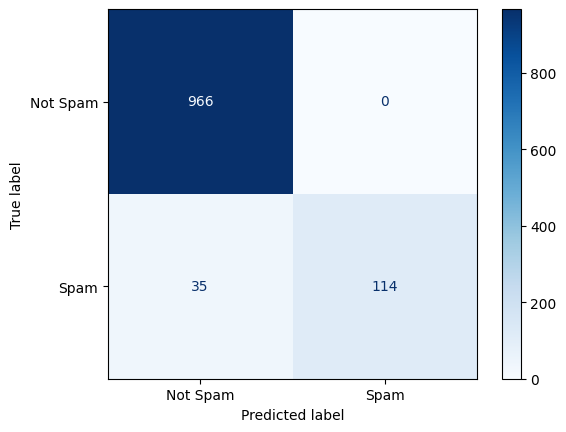

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

#loading the dataset
df = pd.read_csv("spam.csv", encoding="latin-1", usecols=["v1", "v2"])
print("The Dataset look like : -\n")
print(df.head(3))

#renaming columns
df.columns = ["label", "message"]

#encoding labels
df["label"] = df["label"].map({"not spam": 0, "spam": 1})

#splitting datasets into train test split
X_train, X_test, y_train, y_test = train_test_split(df["message"], df["label"], test_size=0.2,
random_state=42, stratify=df["label"]
)

#model building
model = make_pipeline(TfidfVectorizer(stop_words="english"), MultinomialNB())
model.fit(X_train, y_train)

#making predictions
y_pred = model.predict(X_test)


#Evaluation Metrics
print("\n")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))

#Defining Confusion Matrix and printing
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Spam","Spam"])
disp.plot(cmap="Blues")
plt.show()